## Path Initialization

This cell sets the path to the processed data directory.


In [18]:
from pathlib import Path
cur = Path.cwd().resolve()
print("CWD:", cur)

ROOT = None
for i in range(10):
    candidate = cur.parents[i] if i < len(cur.parents) else None
    if candidate is None:
        break
    if (candidate / "results").exists():
        ROOT = candidate
        break


PROCESSED_DIR = ROOT / "data" / "processed"

CWD: E:\A1_last_version\notebooks\modeling


## Label Encoding Setup

This cell loads the label-to-ID mappings and prepares the list of class names for model training and evaluation.


In [19]:

import json
from pathlib import Path
import numpy as np


LABEL2ID_PATH = ROOT / "results" / "preds" / "label2id.json"
ID2LABEL_PATH = ROOT / "results" / "preds" / "id2label.json"

label2id = json.loads(LABEL2ID_PATH.read_text(encoding="utf-8"))
id2label = json.loads(ID2LABEL_PATH.read_text(encoding="utf-8"))
id2label = {int(k): v for k, v in id2label.items()}  # json key transfer int


classes = np.array([id2label[i] for i in range(len(id2label))], dtype=object)

print("Loaded classes:", len(classes))
print("First 5 classes:", classes[:5])

Loaded classes: 18
First 5 classes: ['Above ear - pull hair' 'Cheek - pinch skin' 'Drink from bottle/cup'
 'Eyebrow - pull hair' 'Eyelash - pull hair']


## Experiment Output Setup

This cell defines file paths for saving model checkpoints and prediction outputs.


In [20]:


from pathlib import Path
import numpy as np
import torch


MODELS_DIR = ROOT / "results" / "models"
PREDS_DIR  = ROOT / "results" / "preds"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PREDS_DIR.mkdir(parents=True, exist_ok=True)

MODEL2_CKPT = MODELS_DIR / "fft_mlp_imu_thm_only.pth"
MODEL2_TEST_LOGITS = PREDS_DIR / "fft_mlp_imu_thm_only_test_logits.npy"
MODEL2_TEST_Y = PREDS_DIR / "fft_mlp_imu_thm_only_test_y.npy"
MODEL2_TEST_SEQ_IDS = PREDS_DIR / "fft_mlp_imu_thm_only_test_seq_ids.npy"
MODEL2_CLASSES      = PREDS_DIR / "fft_mlp_imu_thm_only_classes.npy"

print("Model2 ckpt will be saved to:", MODEL2_CKPT)


Model2 ckpt will be saved to: E:\A1_last_version\results\models\fft_mlp_imu_thm_only.pth


## Environment Check

This cell checks whether PyTorch is installed.


In [21]:
import importlib.util
print("torch installed?", importlib.util.find_spec("torch") is not None)



torch installed? True


In [22]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install torch torchvision torchaudio


## Device Configuration

This cell checks the PyTorch version and whether GPU support is available.


In [23]:
import torch
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


torch version: 2.1.0
cuda available: True


## Training Setup

This cell imports required libraries, sets a fixed random seed for reproducibility, and selects CPU/GPU for training


In [24]:
import os, random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


## Data Loading for Model Training

This cell defines the input features and label column, then loads the cleaned dataset for training.


In [25]:
TRAIN_PATH = PROCESSED_DIR / "train_cleaned.csv"

SEQ_COL = "sequence_id"
IMU_COLS = ["acc_x","acc_y","acc_z","rot_w","rot_x","rot_y","rot_z"]
THM_COLS = ["thm_1","thm_2","thm_3","thm_4","thm_5"]
FEATURE_COLS = IMU_COLS + THM_COLS

# find the name of column name
head = pd.read_csv(TRAIN_PATH, nrows=5)
print("Columns:", list(head.columns))


LABEL_COL = "gesture"  

usecols = [SEQ_COL] + FEATURE_COLS + [LABEL_COL]
df = pd.read_csv(TRAIN_PATH, usecols=usecols)

print(df.shape)
df.head()


Columns: ['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject', 'orientation', 'behavior', 'phase', 'gesture', 'acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'thm_1', 'thm_2', 'thm_3', 'thm_4', 'thm_5', 'tof_1_v0', 'tof_1_v1', 'tof_1_v2', 'tof_1_v3', 'tof_1_v4', 'tof_1_v5', 'tof_1_v6', 'tof_1_v7', 'tof_1_v8', 'tof_1_v9', 'tof_1_v10', 'tof_1_v11', 'tof_1_v12', 'tof_1_v13', 'tof_1_v14', 'tof_1_v15', 'tof_1_v16', 'tof_1_v17', 'tof_1_v18', 'tof_1_v19', 'tof_1_v20', 'tof_1_v21', 'tof_1_v22', 'tof_1_v23', 'tof_1_v24', 'tof_1_v25', 'tof_1_v26', 'tof_1_v27', 'tof_1_v28', 'tof_1_v29', 'tof_1_v30', 'tof_1_v31', 'tof_1_v32', 'tof_1_v33', 'tof_1_v34', 'tof_1_v35', 'tof_1_v36', 'tof_1_v37', 'tof_1_v38', 'tof_1_v39', 'tof_1_v40', 'tof_1_v41', 'tof_1_v42', 'tof_1_v43', 'tof_1_v44', 'tof_1_v45', 'tof_1_v46', 'tof_1_v47', 'tof_1_v48', 'tof_1_v49', 'tof_1_v50', 'tof_1_v51', 'tof_1_v52', 'tof_1_v53', 'tof_1_v54', 'tof_1_v55', 'tof_1_v56', 'tof_1_v57', 'tof_1_v58', 'tof_

,sequence_id,gesture,acc_x,acc_y,acc_z,rot_w,rot_x,rot_y,rot_z,thm_1,thm_2,thm_3,thm_4,thm_5
0,SEQ_000007,Cheek - pinch skin,6.683594,6.214844,3.355469,0.134399,-0.355164,-0.447327,-0.809753,28.943842,31.822186,29.553024,28.592863,28.310535
1,SEQ_000007,Cheek - pinch skin,6.949219,6.214844,3.125000,0.143494,-0.340271,-0.428650,-0.824524,29.340816,31.874645,29.791740,28.663383,28.406172
2,SEQ_000007,Cheek - pinch skin,5.722656,5.410156,5.421875,0.219055,-0.274231,-0.356934,-0.865662,30.339359,30.935045,30.090014,28.796087,28.529778
3,SEQ_000007,Cheek - pinch skin,6.601562,3.531250,6.457031,0.297546,-0.264160,-0.238159,-0.885986,30.543730,27.044001,29.310717,29.018711,27.402010
4,SEQ_000007,Cheek - pinch skin,5.566406,0.277344,9.632812,0.333557,-0.218628,-0.063538,-0.914856,29.317265,25.270855,26.808746,29.408604,27.357603


## Fixed-Length Sequence Preparation

This cell converts variable-length sequences into fixed-length tensors using padding or truncation, making them suitable for model training.


In [26]:


seq_lengths = df.groupby(SEQ_COL).size()
L = int(seq_lengths.median())   
print("Fixed length L =", L)

def pad_trunc(arr, L):
    T, F = arr.shape
    if T >= L:
        return arr[:L]
    out = np.zeros((L, F), dtype=np.float32)
    out[:T] = arr.astype(np.float32)
    return out

X_list, y_list, seq_ids_list = [], [], []

for sid, g in df.groupby(SEQ_COL, sort=False):
    x = g[FEATURE_COLS].to_numpy(dtype=np.float32)  # (T,F)
    x = pad_trunc(x, L)                             # (L,F)
    y = g[LABEL_COL].iloc[0]                        # one seq one label
    X_list.append(x)
    y_list.append(y)
    seq_ids_list.append(sid)                        #  sequence_id

X_seq   = np.stack(X_list)                          # (N,L,F)
y_raw   = np.array(y_list)
seq_ids = np.array(seq_ids_list)                    # seq_ids and  X_seq

print("X_seq:", X_seq.shape, "y:", y_raw.shape, "seq_ids:", seq_ids.shape)
print("First 5 seq_ids:", seq_ids[:5])


Fixed length L = 59
X_seq: (7588, 59, 12) y: (7588,) seq_ids: (7588,)
First 5 seq_ids: ['SEQ_000007' 'SEQ_000008' 'SEQ_000013' 'SEQ_000016' 'SEQ_000018']


## FFT Feature Extraction

This cell converts time-domain sequences into frequency-domain features using FFT, then reshapes them for model input.


In [27]:
fft = np.fft.rfft(X_seq, axis=1)        # 沿时间维做 FFT
fft_mag = np.abs(fft).astype(np.float32)
X_fft = fft_mag.reshape(fft_mag.shape[0], -1)
print("X_fft:", X_fft.shape)


X_fft: (7588, 360)


## Data Preparation for Training

This cell encodes labels, applies a predefined train/test split based on sequence IDs, and standardizes the input features.


In [28]:
import sys
import numpy as np
from sklearn.preprocessing import StandardScaler

# use global label2id.json
y_raw_str = np.array([str(x) for x in y_raw], dtype=object)
y_int = np.array([label2id[s] for s in y_raw_str], dtype=int)

num_classes = len(classes)
print("num_classes:", num_classes)

# use global split
if 'numpy._core' not in sys.modules:
    sys.modules['numpy._core'] = sys.modules['numpy.core']
if 'numpy._core.multiarray' not in sys.modules:
    sys.modules['numpy._core.multiarray'] = sys.modules['numpy.core.multiarray']

# Now try loading again!
split_train = np.load(PREDS_DIR / "split_train_seq_ids.npy", allow_pickle=True)
split_test  = np.load(PREDS_DIR / "split_test_seq_ids.npy", allow_pickle=True)
split_train = np.load(PREDS_DIR / "split_train_seq_ids.npy", allow_pickle=True)
split_test  = np.load(PREDS_DIR / "split_test_seq_ids.npy", allow_pickle=True)

split_train = list(map(str, split_train))
split_test  = list(map(str, split_test))

print("Loaded global split:",
      "train =", len(split_train),
      "test  =", len(split_test),
      "first 5 test =", split_test[:5])

# create seq_id -> index
seq_ids_str = list(map(str, list(seq_ids)))
idx_map = {sid: i for i, sid in enumerate(seq_ids_str)}

# use global split to get index
missing_train = [sid for sid in split_train if sid not in idx_map]
missing_test  = [sid for sid in split_test  if sid not in idx_map]

print("missing_train:", len(missing_train), "missing_test:", len(missing_test))
if len(missing_train) > 0:
    print("Example missing_train:", missing_train[:5])
if len(missing_test) > 0:
    print("Example missing_test:", missing_test[:5])


assert len(missing_train) == 0 and len(missing_test) == 0, "Global split contains seq_ids not found in this notebook!"

train_idx = np.array([idx_map[sid] for sid in split_train], dtype=int)
test_idx  = np.array([idx_map[sid] for sid in split_test], dtype=int)

#
X_train = X_fft[train_idx]
X_test  = X_fft[test_idx]
y_train = y_int[train_idx]
y_test  = y_int[test_idx]

#
test_seq_ids = np.array(split_test, dtype=object)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape, "test_seq_ids:", test_seq_ids.shape)
print("First 5 test_seq_ids:", test_seq_ids[:5])

#
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

num_classes: 18
Loaded global split: train = 6070 test  = 1518 first 5 test = ['SEQ_000007', 'SEQ_000053', 'SEQ_000063', 'SEQ_000079', 'SEQ_000092']
missing_train: 0 missing_test: 0
X_train: (6070, 360) y_train: (6070,)
X_test : (1518, 360) y_test : (1518,) test_seq_ids: (1518,)
First 5 test_seq_ids: ['SEQ_000007' 'SEQ_000053' 'SEQ_000063' 'SEQ_000079' 'SEQ_000092']


## FFT-MLP Model Definition and Training

In this cell, I define and train a Multilayer Perceptron model using the FFT-transformed features.

### Model Architecture
- Input layer: `in_dim` (flattened FFT features)
- Hidden layers: 128 → 64 → 64 units with ReLU activation
- Output layer: `out_dim` (number of gesture classes)

### Training Setup
- Optimizer: Adam (learning rate = 0.001)
- Loss function: CrossEntropyLoss (multi-class classification)
- Batch size: 256
- Epochs: 20

The model is trained using mini-batch gradient descent. Training loss is printed after each epoch.


In [29]:
from sklearn.metrics import f1_score
import numpy as np


BFRB_CLASSES = {
    "Above ear - pull hair",
    "Cheek - pinch skin",
    "Eyebrow - pull hair",
    "Eyelash - pull hair",
    "Forehead - pull hairline",
    "Forehead - scratch",
    "Neck - pinch skin",
    "Neck - scratch",
}



classes = list(classes) 

BFRB_INDEX_SET = set()

for i, c in enumerate(classes):
    if c in BFRB_CLASSES:
        BFRB_INDEX_SET.add(i)

print("BFRB index set:", BFRB_INDEX_SET)
def to_binary(y_array):
    y_binary = []

    for y in y_array:
        if int(y) in BFRB_INDEX_SET:
            y_binary.append(1)
        else:
            y_binary.append(0)

    return np.array(y_binary, dtype=np.int64)


class MLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, out_dim),
        )

    def forward(self, x):
        return self.net(x)


model = MLP(X_train.shape[1], num_classes).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test).long())

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

train_losses = []
test_losses = []
test_f1_bin_list = []
test_f1_macro_list = []

for epoch in range(1, 21):

    # ------------------
    # Training
    # ------------------
    model.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()

        total_train_loss += loss.item() * xb.size(0)

    avg_train_loss = total_train_loss / len(train_ds)
    train_losses.append(avg_train_loss)

    # ------------------
    # Evaluation
    # ------------------
    model.eval()
    total_test_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = loss_fn(logits, yb)

            total_test_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_ds)
    test_losses.append(avg_test_loss)

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Macro F1
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    test_f1_macro_list.append(macro_f1)

    # Binary F1
    y_true_bin_epoch = to_binary(all_labels)
    y_pred_bin_epoch = to_binary(all_preds)

    bin_f1 = f1_score(y_true_bin_epoch, y_pred_bin_epoch)
    test_f1_bin_list.append(bin_f1)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss={avg_train_loss:.4f} | "
        f"Test Loss={avg_test_loss:.4f} | "
        f"Binary F1={bin_f1:.4f} | "
        f"Macro F1={macro_f1:.4f}"
    )


BFRB index set: {0, 1, 3, 4, 6, 7, 9, 10}
Epoch 01 | Train Loss=2.7427 | Test Loss=2.5659 | Binary F1=0.7148 | Macro F1=0.0826
Epoch 02 | Train Loss=2.4430 | Test Loss=2.3482 | Binary F1=0.7434 | Macro F1=0.1431
Epoch 03 | Train Loss=2.2317 | Test Loss=2.1891 | Binary F1=0.8219 | Macro F1=0.1917
Epoch 04 | Train Loss=2.0562 | Test Loss=2.0369 | Binary F1=0.8849 | Macro F1=0.2476
Epoch 05 | Train Loss=1.9064 | Test Loss=1.9764 | Binary F1=0.8815 | Macro F1=0.2768
Epoch 06 | Train Loss=1.8054 | Test Loss=1.8993 | Binary F1=0.9002 | Macro F1=0.3409
Epoch 07 | Train Loss=1.7230 | Test Loss=1.8598 | Binary F1=0.9035 | Macro F1=0.3569
Epoch 08 | Train Loss=1.6534 | Test Loss=1.8484 | Binary F1=0.9102 | Macro F1=0.3515
Epoch 09 | Train Loss=1.5999 | Test Loss=1.8454 | Binary F1=0.9098 | Macro F1=0.3464
Epoch 10 | Train Loss=1.5487 | Test Loss=1.8250 | Binary F1=0.9139 | Macro F1=0.3788
Epoch 11 | Train Loss=1.4985 | Test Loss=1.8203 | Binary F1=0.9083 | Macro F1=0.3614
Epoch 12 | Train Loss=1

## Model Checkpoint

This cell saves the trained MLP model for future use.


In [30]:

torch.save(model.state_dict(), MODEL2_CKPT)
print("Saved Model2 checkpoint to:", MODEL2_CKPT)




Saved Model2 checkpoint to: E:\A1_last_version\results\models\fft_mlp_imu_thm_only.pth


## Test Evaluation

This cell evaluates the model on the test set and computes the macro-averaged F1-score.


In [31]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        p = model(xb).argmax(dim=1).cpu().numpy()
        preds.append(p)
        trues.append(yb.numpy())

y_pred = np.concatenate(preds)
y_true = np.concatenate(trues)

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Classes:", list(classes))


Macro F1: 0.40259816163793594
Classes: ['Above ear - pull hair', 'Cheek - pinch skin', 'Drink from bottle/cup', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Feel around in tray and pull out an object', 'Forehead - pull hairline', 'Forehead - scratch', 'Glasses on/off', 'Neck - pinch skin', 'Neck - scratch', 'Pinch knee/leg skin', 'Pull air toward your face', 'Scratch knee/leg skin', 'Text on phone', 'Wave hello', 'Write name in air', 'Write name on leg']


## Export Test Predictions

This cell generates test logits and saves logits, labels, sequence IDs, and class names for reproducible evaluation and future ensemble steps.


In [32]:


import numpy as np
import torch

model.eval()
DEVICE = next(model.parameters()).device

all_logits = []
all_y = []

with torch.no_grad():
    for x, y in test_loader:

        if not torch.is_tensor(x):
            x = torch.as_tensor(x, dtype=torch.float32)
        if not torch.is_tensor(y):
            y = torch.as_tensor(y, dtype=torch.long)

        x = x.to(DEVICE)
        y = y.to(DEVICE)


        if y.ndim > 1:
            y = y.view(-1)

        logits = model(x)
        all_logits.append(logits.detach().cpu().numpy())
        all_y.append(y.detach().cpu().numpy())


if len(all_logits) == 0:
    raise RuntimeError("test_loader is empty; check your test split / loader.")

all_logits = np.concatenate(all_logits, axis=0)
all_y = np.concatenate(all_y, axis=0)


test_seq_ids_np = np.asarray(test_seq_ids, dtype=object)

#
assert all_logits.shape[0] == all_y.shape[0] == test_seq_ids_np.shape[0], \
    (all_logits.shape, all_y.shape, test_seq_ids_np.shape)

assert test_seq_ids_np.shape[0] == 1518, \
    f"Expected GLOBAL test size 1518, but got {test_seq_ids_np.shape[0]}. Did you load split_test_seq_ids.npy?"

print("Model2 test pack confirmed as GLOBAL split_test_seq_ids (1518).")

np.save(MODEL2_TEST_LOGITS, all_logits)
np.save(MODEL2_TEST_Y, all_y)

np.save(MODEL2_TEST_SEQ_IDS, np.asarray(test_seq_ids))

np.save(MODEL2_CLASSES, np.asarray(classes, dtype=object))

print("Saved Model2 test logits:", MODEL2_TEST_LOGITS, all_logits.shape)
print("Saved Model2 test y:", MODEL2_TEST_Y, all_y.shape)
print("Saved Model2 test seq_ids:", MODEL2_TEST_SEQ_IDS, np.asarray(test_seq_ids).shape)
print("Saved Model2 classes:", MODEL2_CLASSES, np.asarray(classes).shape)
print("First 5 test_seq_ids:", np.asarray(test_seq_ids)[:5])



Model2 test pack confirmed as GLOBAL split_test_seq_ids (1518).
Saved Model2 test logits: E:\A1_last_version\results\preds\fft_mlp_imu_thm_only_test_logits.npy (1518, 18)
Saved Model2 test y: E:\A1_last_version\results\preds\fft_mlp_imu_thm_only_test_y.npy (1518,)
Saved Model2 test seq_ids: E:\A1_last_version\results\preds\fft_mlp_imu_thm_only_test_seq_ids.npy (1518,)
Saved Model2 classes: E:\A1_last_version\results\preds\fft_mlp_imu_thm_only_classes.npy (18,)
First 5 test_seq_ids: ['SEQ_000007' 'SEQ_000053' 'SEQ_000063' 'SEQ_000079' 'SEQ_000092']


## Binary F1 Evaluation

This cell converts multi-class predictions into binary labels (BFRB vs non-BFRB) and computes the binary F1-score.


In [33]:

import json
from pathlib import Path
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np

# already have：classes, y_true, y_pred
# classes is np.str_，turn into regular str
classes_str = np.array([str(c) for c in classes], dtype=object)

BFRB = {
    "Above ear - pull hair",
    "Cheek - pinch skin",
    "Eyebrow - pull hair",
    "Eyelash - pull hair",
    "Forehead - pull hairline",
    "Forehead - scratch",
    "Neck - pinch skin",
    "Neck - scratch",
}

def to_binary(y_int_arr):
    names = classes_str[y_int_arr]
    return np.array([1 if n in BFRB else 0 for n in names], dtype=int)

y_true_bin = to_binary(y_true)
y_pred_bin = to_binary(y_pred)

bin_f1 = f1_score(y_true_bin, y_pred_bin)

acc = accuracy_score(y_true, y_pred)
macroF1 = f1_score(y_true, y_pred, average="macro")
binaryF1 = bin_f1

print("Acc:", acc)
print("Macro F1:", macroF1)
print("Binary F1:", binaryF1)
print("Binary F1 (BFRB vs non-BFRB):", bin_f1)

print("\nConfusion matrix [[TN, FP],[FN, TP]]:")
print(confusion_matrix(y_true_bin, y_pred_bin))

print("\nBinary classification report:")
print(classification_report(y_true_bin, y_pred_bin, target_names=["non-BFRB","BFRB"]))

ARTIFACT_DIR = ROOT / "results" / "Model2_Training"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

summary = {
    "final_metrics": {
        "acc": float(acc),
        "macroF1": float(macroF1),
        "binaryF1": float(binaryF1)
    }
}

out_path = ARTIFACT_DIR / "model2_training_summary.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:", out_path)

Acc: 0.38801054018445325
Macro F1: 0.40259816163793594
Binary F1: 0.9133192389006344
Binary F1 (BFRB vs non-BFRB): 0.9133192389006344

Confusion matrix [[TN, FP],[FN, TP]]:
[[490  76]
 [ 88 864]]

Binary classification report:
              precision    recall  f1-score   support

    non-BFRB       0.85      0.87      0.86       566
        BFRB       0.92      0.91      0.91       952

    accuracy                           0.89      1518
   macro avg       0.88      0.89      0.88      1518
weighted avg       0.89      0.89      0.89      1518

Saved: E:\A1_last_version\results\Model2_Training\model2_training_summary.json


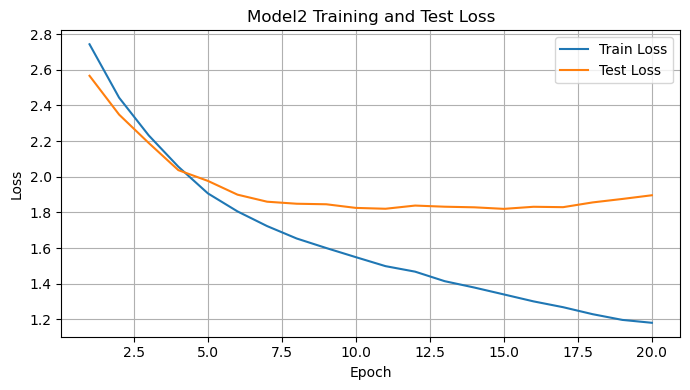

Saved: E:\A1_last_version\plots\model2_training_curves\loss_curve.png


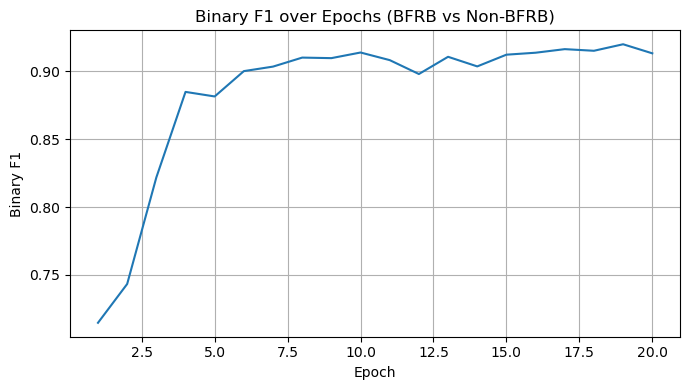

Saved: E:\A1_last_version\plots\model2_training_curves\binary_f1_curve.png


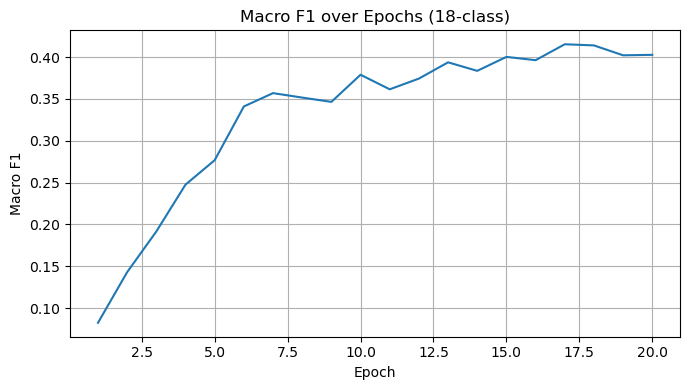

Saved: E:\A1_last_version\plots\model2_training_curves\macro_f1_curve.png


In [34]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Create plot directory
# =========================
PLOT_DIR = ROOT / "plots" / "model2_training_curves"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

epochs = range(1, len(train_losses) + 1)

# =========================
# 1. Loss Curve
# =========================
plt.figure(figsize=(7,4))
plt.plot(epochs, train_losses)
plt.plot(epochs, test_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model2 Training and Test Loss")
plt.legend(["Train Loss", "Test Loss"])
plt.grid(True)

loss_path = PLOT_DIR / "loss_curve.png"
plt.tight_layout()
plt.savefig(loss_path, dpi=300)
plt.show()    
plt.close()

print("Saved:", loss_path)


# =========================
# 2. Binary F1 Curve
# =========================
plt.figure(figsize=(7,4))
plt.plot(epochs, test_f1_bin_list)

plt.xlabel("Epoch")
plt.ylabel("Binary F1")
plt.title("Binary F1 over Epochs (BFRB vs Non-BFRB)")
plt.grid(True)

bin_path = PLOT_DIR / "binary_f1_curve.png"
plt.tight_layout()
plt.savefig(bin_path, dpi=300)
plt.show()    
plt.close()

print("Saved:", bin_path)


# =========================
# 3. Macro F1 Curve
# =========================
plt.figure(figsize=(7,4))
plt.plot(epochs, test_f1_macro_list)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 over Epochs (18-class)")
plt.grid(True)

macro_path = PLOT_DIR / "macro_f1_curve.png"
plt.tight_layout()
plt.savefig(macro_path, dpi=300)
plt.show()    
plt.close()

print("Saved:", macro_path)
